# Assignment 2: Image Captioning with PyTorch RNNs and LSTMs

**Student ID:** 2025320626

**Name:** KON FAN SAN OLEG

**Grading (100 points)**

| Item | Topic | Points |
|---|---|---:|
| 1.1 | Vanilla RNN Cell | 8 |
| 1.2 | Vanilla RNN over a Sequence | 8 |
| 1.3 | RNN Captioning Module | 14 |
| 1.4 | PyTorch Training Loop | 10 |
| 1.5 | Greedy Sampling | 6 |
| 1.6 | Character-Level Captioning | 4 |
|  | **Part 1 subtotal** | **50** |
| 2.1 | LSTM Cell | 12 |
| 2.2 | LSTM over a Sequence | 10 |
| 2.3 | LSTM Captioning Module | 12 |
| 2.4 | Train the LSTM Captioner | 8 |
| 2.5 | LSTM Greedy Sampling | 4 |
| 2.6 | LSTM Gate Activations | 4 |
|  | **Part 2 subtotal** | **50** |
|  | **Total** | **100** |


## Assignment Overview

In this assignment, you will implement recurrent neural networks in PyTorch and
apply them to image captioning on MS-COCO. You will explicitly implement the
recurrent update equations while using PyTorch autograd for backward propagation.

- **Part 1 — Vanilla RNN Captioning:** Implement a Vanilla RNN cell, unroll it
  over a sequence, build an RNN image-captioning model, train it, and generate
  captions with greedy sampling.
- **Part 2 — LSTM Captioning:** Implement an LSTM cell and sequence model, build
  an LSTM image-captioning model, train it, and generate captions while tracking
  both hidden and cell states.

### Goals

- Understand how recurrent networks share parameters across timesteps.
- Implement Vanilla RNN and LSTM cells using `torch.Tensor` operations.
- Build sequence modules from recurrent cells without using `nn.RNN` or `nn.LSTM`.
- Combine precomputed CNN image features with a recurrent language model.
- Train captioning models with PyTorch autograd and optimizers.
- Generate captions using greedy test-time sampling.

### References and Conventions

Statements labeled **Lecture Connection** point to relevant material from
*Lec01 Foundations of Deep Learning*; the cited page numbers refer to that PDF.
RNN- and LSTM-specific explanations are labeled **Concept Connection** because
those topics are not covered in Lec01.

Unless stated otherwise, `N` is batch size, `T` is sequence length, `D` is the
input-feature dimension, `W` is the word-vector dimension, `H` is the hidden
dimension, and `V` is vocabulary size.

Run the notebook from top to bottom. Do not use `nn.RNN`, `nn.RNNCell`,
`nn.LSTM`, or `nn.LSTMCell` in your implementations; they are used only in the
provided reference checks.


## Colab Setup: Download the COCO Captioning Dataset

The archive contains captions and precomputed VGG-16 image features. Its size is
approximately 1 GB. The download is skipped if the extracted directory already
exists in the current runtime.


In [2]:
%%bash
set -euo pipefail

DATASET_DIR="datasets"
COCO_DIR="$DATASET_DIR/coco_captioning"
ARCHIVE="$DATASET_DIR/coco_captioning.zip"
URL="https://cs231n.stanford.edu/coco_captioning.zip"

mkdir -p "$DATASET_DIR"
if [ ! -d "$COCO_DIR" ]; then
  echo "Downloading COCO captioning data..."
  curl -L --fail --show-error "$URL" -o "$ARCHIVE"
  unzip -q "$ARCHIVE" -d "$DATASET_DIR"
  rm "$ARCHIVE"
  echo "COCO captioning data are ready."
else
  echo "COCO captioning data already exist; skipping download."
fi


COCO captioning data are ready.


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  987M  100  987M    0     0  10.7M      0  0:01:31  0:01:31 --:--:-- 11.1M


In [3]:
%pip install -q h5py imageio


#### Setup


In [4]:
import json
import os
import random
import tempfile
import urllib.error
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from imageio.v2 import imread
from torch.utils.data import DataLoader, Dataset

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

SEED = 231
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def max_relative_error(x, y, eps=1e-8):
    """Return the maximum elementwise relative error between two tensors."""
    x = x.detach().cpu()
    y = y.detach().cpu()
    return ((x - y).abs() / torch.clamp(x.abs() + y.abs(), min=eps)).max().item()


Using device: cpu


#### Provided: COCO Data Utilities and Temporal Loss

The following code loads the precomputed image features and captions. Students
do not need to modify these helpers.


In [5]:
COCO_DIR = Path('datasets/coco_captioning')


def load_coco_data(base_dir=COCO_DIR, pca_features=True):
    base_dir = Path(base_dir)
    data = {}

    with h5py.File(base_dir / 'coco2014_captions.h5', 'r') as f:
        for key, value in f.items():
            data[key] = np.asarray(value)

    train_name = 'train2014_vgg16_fc7_pca.h5' if pca_features else 'train2014_vgg16_fc7.h5'
    val_name = 'val2014_vgg16_fc7_pca.h5' if pca_features else 'val2014_vgg16_fc7.h5'
    with h5py.File(base_dir / train_name, 'r') as f:
        data['train_features'] = np.asarray(f['features'], dtype=np.float32)
    with h5py.File(base_dir / val_name, 'r') as f:
        data['val_features'] = np.asarray(f['features'], dtype=np.float32)

    with open(base_dir / 'coco2014_vocab.json') as f:
        data.update(json.load(f))
    with open(base_dir / 'train2014_urls.txt') as f:
        data['train_urls'] = np.asarray([line.strip() for line in f])
    with open(base_dir / 'val2014_urls.txt') as f:
        data['val_urls'] = np.asarray([line.strip() for line in f])
    return data


def decode_captions(captions, idx_to_word):
    captions = np.asarray(captions)
    single = captions.ndim == 1
    if single:
        captions = captions[None]
    decoded = []
    for caption in captions:
        words = []
        for token in caption:
            word = idx_to_word[int(token)]
            if word != '<NULL>':
                words.append(word)
            if word == '<END>':
                break
        decoded.append(' '.join(words))
    return decoded[0] if single else decoded


def image_from_url(url):
    try:
        response = urllib.request.urlopen(url, timeout=10)
        fd, filename = tempfile.mkstemp()
        os.close(fd)
        with open(filename, 'wb') as f:
            f.write(response.read())
        image = imread(filename)
        os.remove(filename)
        return image
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError) as exc:
        print('Could not download image:', exc)
        return None


class CocoCaptionDataset(Dataset):
    """A PyTorch view of the precomputed COCO captioning arrays."""

    def __init__(self, data, split='train', max_examples=None, seed=SEED):
        captions = data[f'{split}_captions']
        image_idxs = data[f'{split}_image_idxs']
        if max_examples is not None and max_examples < len(captions):
            rng = np.random.default_rng(seed)
            keep = rng.choice(len(captions), size=max_examples, replace=False)
            captions = captions[keep]
            image_idxs = image_idxs[keep]
        self.captions = captions.astype(np.int64)
        self.image_idxs = image_idxs.astype(np.int64)
        self.features = data[f'{split}_features']

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, index):
        feature = self.features[self.image_idxs[index]]
        return torch.from_numpy(feature).float(), torch.from_numpy(self.captions[index]).long()


def temporal_cross_entropy(logits, targets, null_index):
    """Cross-entropy over all non-NULL tokens."""
    return F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
        ignore_index=null_index,
    )


In [6]:
# Load the dataset once for both the RNN and LSTM parts.
data = load_coco_data(pca_features=True)
for key, value in data.items():
    if isinstance(value, np.ndarray):
        print(f'{key}: {value.shape}')

input_dim = data['train_features'].shape[1]
vocab_size = len(data['word_to_idx'])
null_index = data['word_to_idx']['<NULL>']
start_index = data['word_to_idx']['<START>']
print('input_dim:', input_dim, 'vocab_size:', vocab_size)


train_captions: (400135, 17)
train_image_idxs: (400135,)
val_captions: (195954, 17)
val_image_idxs: (195954,)
train_features: (82783, 512)
val_features: (40504, 512)
train_urls: (82783,)
val_urls: (40504,)
input_dim: 512 vocab_size: 1004


## Part 1: Vanilla RNN Captioning (50 points)

A Vanilla RNN updates its hidden state using

$$h_t = \tanh(x_tW_x + h_{t-1}W_h + b).$$

The same parameters are reused at every timestep. PyTorch autograd will compute
the backward pass through the complete unrolled computation graph.


### Section 1: Vanilla RNN Cell and Sequence



#### Question 1.1: Vanilla RNN Cell [code] (8 points)

Implement one recurrent update without using `nn.RNNCell`.

**Lecture Connection**

> During forward pass, PyTorch records operations needed for gradient computation.  
> *(Lecture, p. 49)*

**Concept Connection**

The cell uses the same learnable parameters at every timestep:

$$h_t = \tanh(x_tW_x + h_{t-1}W_h + b).$$

Because the update consists only of PyTorch tensor operations, autograd can
differentiate through it without a manually written backward function.

**Implementation Guide and Point Breakdown**

- **Parameter setup (4 points):** Register `Wx`, `Wh`, and `b` as
  `nn.Parameter` objects. Initialize each weight with a scale based on its input
  dimension and initialize the bias to zero.
- **Forward update (4 points):** Compute the affine input and recurrent terms,
  add the broadcast bias, and apply `torch.tanh`.

| Tensor | Shape |
|---|---|
| `x` | `(N, D)` |
| `prev_h` | `(N, H)` |
| `Wx` | `(D, H)` |
| `Wh` | `(H, H)` |
| `b` | `(H,)` |
| `next_h` | `(N, H)` |

**Expected Check:** Forward relative error below `1e-7`, with an autograd
gradient present for every parameter.


In [7]:
class VanillaRNNCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        ########################################################################
        # TODO 1.1 (4/8 points): Create Wx, Wh, and b as trainable parameters. #
        ########################################################################
        self.Wx = nn.Parameter(torch.randn(input_dim,hidden_dim)/(input_dim**0.5))
        self.Wh = nn.Parameter(torch.randn(hidden_dim,hidden_dim)/(hidden_dim**0.5))
        self.b = nn.Parameter(torch.zeros(hidden_dim))
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################

    def forward(self, x, prev_h):
        ########################################################################
        # TODO 1.1 (4/8 points): Implement h_t = tanh(xWx + h_{t-1}Wh + b).  #
        ########################################################################
        next_h = torch.tanh(x@self.Wx + prev_h@self.Wh + self.b)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return next_h


In [8]:
# Provided check: compare your cell with torch.nn.RNNCell.
torch.manual_seed(SEED)
N, D, H = 3, 5, 4
x = torch.randn(N, D, dtype=torch.float64)
prev_h = torch.randn(N, H, dtype=torch.float64)

cell = VanillaRNNCell(D, H).double()
reference = nn.RNNCell(D, H, nonlinearity='tanh').double()
with torch.no_grad():
    reference.weight_ih.copy_(cell.Wx.T)
    reference.weight_hh.copy_(cell.Wh.T)
    reference.bias_ih.copy_(cell.b)
    reference.bias_hh.zero_()

out = cell(x, prev_h)
correct = reference(x, prev_h)
print('forward relative error:', max_relative_error(out, correct))
assert max_relative_error(out, correct) < 1e-7

out.square().sum().backward()
assert all(parameter.grad is not None for parameter in cell.parameters())
print('autograd gradients are present for all parameters')


forward relative error: 0.0
autograd gradients are present for all parameters


#### Question 1.2: Vanilla RNN over a Sequence [code] (8 points)

Apply the same cell to all `T` timesteps. Do not create a different cell per
timestep.

**Concept Connection**

Unrolling a recurrent network creates one computation step per token while
reusing a single parameter set. The state from timestep `t` becomes the
`prev_h` input at timestep `t + 1`.

**Implementation Guide**

1. Set the current hidden state to `h0`.
2. Iterate over the `T` positions of `x` and call `self.cell` each time.
3. Append each new hidden state to a Python list.
4. Use `torch.stack(..., dim=1)` to restore the time dimension.

| Tensor | Shape |
|---|---|
| `x` | `(N, T, D)` |
| `h0` | `(N, H)` |
| output `h` | `(N, T, H)` |

**Expected Check:** Sequence relative error below `1e-7` against the provided
`nn.RNN` reference.


In [9]:
class VanillaRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = VanillaRNNCell(input_dim, hidden_dim)

    def forward(self, x, h0):
        ########################################################################
        # TODO 1.2 (8 points): Iterate over time, reuse self.cell, and stack   #
        # every hidden state along dimension 1.                               #
        ########################################################################
        prev_h = h0
        hidden_states = []
        for t in range(x.shape[1]):
          prev_h = self.cell(x[:,t,:],prev_h)
          hidden_states.append(prev_h)
        h = torch.stack(hidden_states, dim=1)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return h


In [10]:
# Provided sequence check against torch.nn.RNN.
torch.manual_seed(SEED)
N, T, D, H = 2, 3, 4, 5
x = torch.randn(N, T, D, dtype=torch.float64)
h0 = torch.randn(N, H, dtype=torch.float64)

model = VanillaRNN(D, H).double()
reference = nn.RNN(D, H, batch_first=True, nonlinearity='tanh').double()
with torch.no_grad():
    reference.weight_ih_l0.copy_(model.cell.Wx.T)
    reference.weight_hh_l0.copy_(model.cell.Wh.T)
    reference.bias_ih_l0.copy_(model.cell.b)
    reference.bias_hh_l0.zero_()

h = model(x, h0)
correct, _ = reference(x, h0.unsqueeze(0))
print('sequence relative error:', max_relative_error(h, correct))
assert max_relative_error(h, correct) < 1e-7


sequence relative error: 9.37096987095509e-16


### Section 2: RNN Captioning Model and Training



#### Question 1.3: RNN Captioning Module [code] (14 points)

The image feature initializes the hidden state. Caption tokens are embedded,
processed by the RNN, and projected to vocabulary logits.

**Lecture Connection**

> During forward pass, PyTorch records operations needed for gradient computation.  
> *(Lecture, p. 49)*

**Concept Connection**

The model predicts **logits**, which are unnormalized vocabulary scores.
`F.cross_entropy` consumes logits directly; probabilities are obtained only
when a softmax is explicitly applied, and the discrete prediction is the index
with the largest logit. Do not apply softmax in `forward`.

**Implementation Guide and Point Breakdown**

- **Module construction (6 points):** Create a feature projection
  (`input_dim → H`), an embedding (`V → W`), a `VanillaRNN` (`W → H`), and a
  vocabulary projection (`H → V`).
- **Forward pass (8 points):** Project the image features to `h0`, embed
  `captions_in`, compute all hidden states, and project them to vocabulary logits.

| Stage | Shape |
|---|---|
| image features | `(N, D)` |
| initial hidden state | `(N, H)` |
| input token indices | `(N, T)` |
| word vectors | `(N, T, W)` |
| recurrent hidden states | `(N, T, H)` |
| vocabulary logits | `(N, T, V)` |

**Expected Check:** The toy model returns logits of shape `(3, 6, 5)`, produces
a finite loss, and gives an autograd gradient to every parameter.


In [37]:
class RNNCaptioner(nn.Module):
    def __init__(self, word_to_idx, input_dim, wordvec_dim=128, hidden_dim=128):
        super().__init__()
        self.word_to_idx = word_to_idx
        self.idx_to_word = {index: word for word, index in word_to_idx.items()}
        self.null_index = word_to_idx['<NULL>']
        self.start_index = word_to_idx['<START>']
        self.hidden_dim = hidden_dim
        vocab_size = len(word_to_idx)

        ########################################################################
        # TODO 1.3 (6/14 points): Create the image projection, word embedding, #
        # VanillaRNN, and vocabulary projection modules.                       #
        ########################################################################
        self.feature_projection = nn.Linear(input_dim, hidden_dim)
        self.embedding = nn.Embedding(vocab_size, wordvec_dim)
        self.rnn = VanillaRNN(wordvec_dim, hidden_dim)
        self.vocab_projection = nn.Linear(hidden_dim,vocab_size)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################

    def forward(self, features, captions_in):
        ########################################################################
        # TODO 1.3 (8/14 points):                                               #
        # 1. Project image features to h0.                                      #
        # 2. Embed captions_in.                                                 #
        # 3. Compute all recurrent hidden states.                               #
        # 4. Project hidden states to vocabulary logits.                        #
        ########################################################################
        h0 = self.feature_projection(features)
        word_vectors = self.embedding(captions_in)
        hidden_states = self.rnn(word_vectors, h0)
        logits = self.vocab_projection(hidden_states)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return logits

    @torch.no_grad()
    def sample(self, features, max_length=30):
        ########################################################################
        # TODO 1.5 (6 points): Implement greedy caption generation. Start with #
        # <START>, update one hidden state at a time, and select argmax logits. #
        ########################################################################
        N = features.shape[0]
        captions = torch.full(
            (N,max_length),
            self.null_index,
            dtype=torch.long,
            device= features.device
        )
        h = self.feature_projection(features)
        current_word = torch.full(
            (N,), self.start_index,dtype = torch.long,device = features.device)

        for t in range(max_length):
          word_vector = self.embedding(current_word)
          h = self.rnn.cell(word_vector,h)
          logits = self.vocab_projection(h)
          next_word = logits.argmax(dim = 1)
          captions[:,t] = next_word
          current_word = next_word
        ########################################################################
        #                         END OF YOUR CODE                             #
        #######################################################################
        return captions

In [12]:
# Provided shape and gradient-flow check.
torch.manual_seed(SEED)
toy_vocab = {'<NULL>': 0, '<START>': 1, '<END>': 2, 'cat': 3, 'dog': 4}
toy_model = RNNCaptioner(toy_vocab, input_dim=6, wordvec_dim=4, hidden_dim=5)
toy_features = torch.randn(3, 6)
toy_captions = torch.randint(0, len(toy_vocab), (3, 7))
toy_logits = toy_model(toy_features, toy_captions[:, :-1])
assert toy_logits.shape == (3, 6, len(toy_vocab))
toy_loss = temporal_cross_entropy(toy_logits, toy_captions[:, 1:], toy_vocab['<NULL>'])
assert torch.isfinite(toy_loss)
toy_loss.backward()
assert all(p.grad is not None for p in toy_model.parameters())
print('logits:', tuple(toy_logits.shape), 'loss:', toy_loss.item())


logits: (3, 6, 5) loss: 1.803063988685608


#### Question 1.4: PyTorch Training Loop [code] (10 points)

**Lecture Connection**

> Each iteration of the training loop samples a batch, computes predictions and
> a loss, computes gradients, and updates the parameters.  
> *(Lecture, p. 52)*

> Use optimizer to update model parameters.  
> *(Lecture, p. 55)*

**Implementation Guide**

For every minibatch, follow this order:

1. Clear accumulated gradients with `optimizer.zero_grad()`.
2. Run the model on `features` and `captions_in` to obtain logits.
3. Compute `temporal_cross_entropy(logits, captions_out, null_index)`.
4. Call `loss.backward()` to populate parameter gradients.
5. Call `optimizer.step()` to update the parameters.

Keep `loss` as a scalar tensor until after `backward`; use `loss.item()` only
when accumulating the displayed epoch loss.

**Expected Check:** On the fixed 100-example subset, the loss should decrease
strongly and should typically finish below `0.5` with the provided configuration.


In [38]:
def train_captioner(model, loader, num_epochs, learning_rate, null_index, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_history = []
    model.to(device)

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        example_count = 0
        for features, captions in loader:
            features = features.to(device)
            captions = captions.to(device)
            captions_in = captions[:, :-1]
            captions_out = captions[:, 1:]

            ####################################################################
            # TODO 1.4 (10 points): Complete one optimizer update. Store the  #
            # scalar loss tensor in the variable `loss`.                      #
            ###################################################################
            optimizer.zero_grad()
            logits = model(features,captions_in)
            loss = temporal_cross_entropy(logits, captions_out,null_index)
            loss.backward()
            optimizer.step()
            ####################################################################
            #                         END OF YOUR CODE                         #
            ####################################################################

            batch_size = features.shape[0]
            epoch_loss += loss.item() * batch_size
            example_count += batch_size

        mean_loss = epoch_loss / example_count
        loss_history.append(mean_loss)
        if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
            print(f'Epoch {epoch:3d}/{num_epochs}: loss {mean_loss:.4f}')

    return loss_history


Epoch   1/60: loss 6.7911
Epoch  10/60: loss 1.0478
Epoch  20/60: loss 0.0946
Epoch  30/60: loss 0.0178
Epoch  40/60: loss 0.0089
Epoch  50/60: loss 0.0063
Epoch  60/60: loss 0.0049


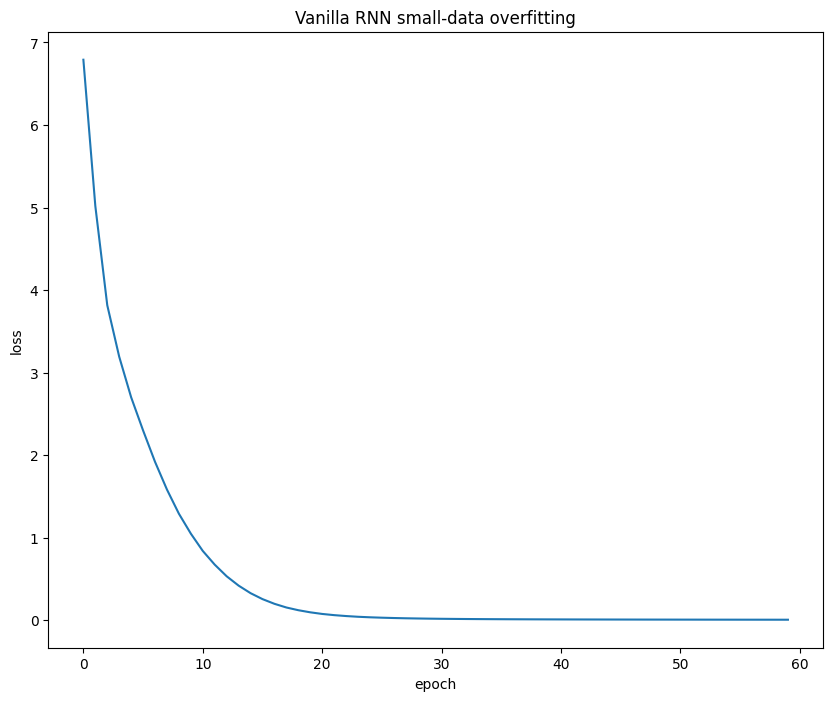

Final RNN loss: 0.00489514647051692


In [39]:
# Overfit a small COCO subset as an end-to-end correctness check.
small_train = CocoCaptionDataset(data, split='train', max_examples=100, seed=SEED)
rnn_loader = DataLoader(small_train, batch_size=50, shuffle=True)

torch.manual_seed(SEED)
rnn_model = RNNCaptioner(
    data['word_to_idx'], input_dim=input_dim, wordvec_dim=128, hidden_dim=256
)
rnn_loss_history = train_captioner(
    rnn_model, rnn_loader, num_epochs=60, learning_rate=5e-3,
    null_index=null_index, device=device,
)

plt.plot(rnn_loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Vanilla RNN small-data overfitting')
plt.show()
print('Final RNN loss:', rnn_loss_history[-1])


#### Question 1.5: Greedy Sampling [code] (6 points)

**Concept Connection**

During training, the model uses ground-truth previous tokens as inputs (teacher forcing). At test time, each predicted token is fed back as the next input. Greedy decoding selects the
largest vocabulary logit at each step.

**Implementation Guide**

1. Project the image features to the initial hidden state.
2. Fill the first input-token tensor with `<START>`.
3. At each timestep, embed the current token, update the RNN cell, project the
   hidden state to vocabulary logits, and select `argmax(dim=1)`.
4. Store each prediction in `captions` and reuse it as the next input token.

| Tensor | Shape |
|---|---|
| `features` | `(N, D)` |
| current token | `(N,)` |
| hidden state | `(N, H)` |
| output `captions` | `(N, max_length)` |

**Expected Check:** After successful small-data overfitting, generated training
captions should contain recognizable words or phrases from their references.


GT:   <START> three baseball players on a field being <UNK> by a crowd <END>
Pred: <END>
Could not download image: HTTP Error 404: Not Found
GT:   <START> giraffes standing in an area of dry grass and small trees <END>
Pred: a cat that is <UNK> flowers <END>


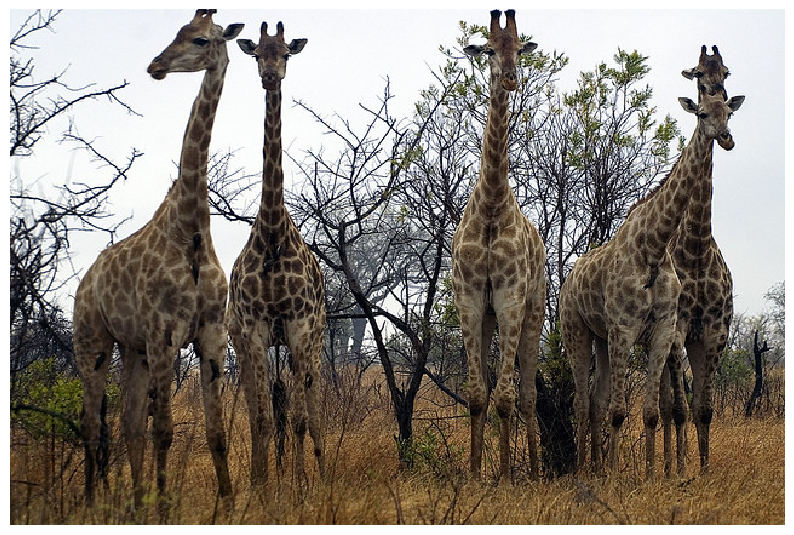

GT:   <START> a group of zebras shown in a outdoor enclosure <END>
Pred: a <UNK> <UNK> fence <END>


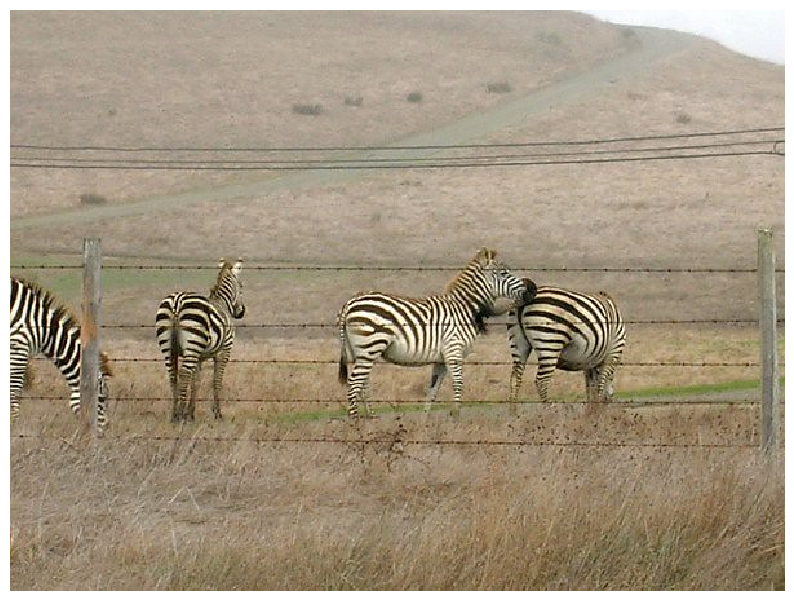

GT:   <START> two transit trains are pulled up at a station with passengers walking <UNK> <END>
Pred: on a sunny day a bus drives in a parking lot <END>


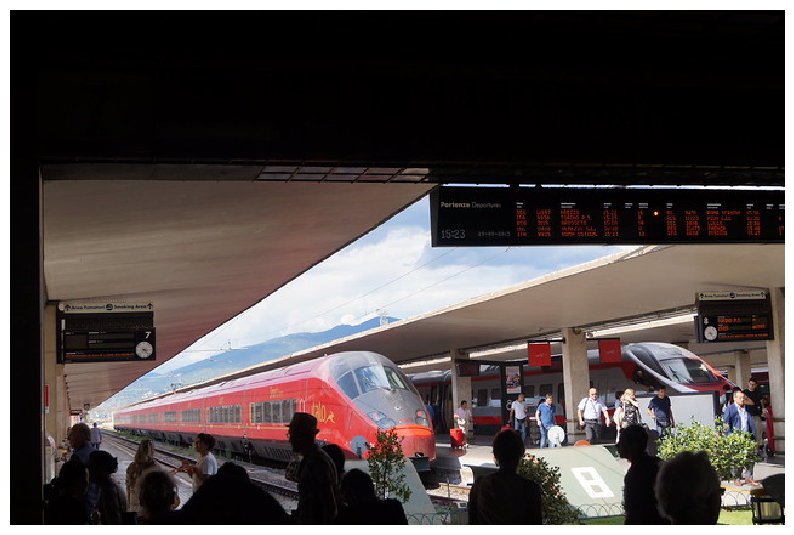

In [41]:
def show_samples(model, data, split='train', count=2):
    model.eval()
    rng = np.random.default_rng(SEED)
    caption_count = len(data[f'{split}_captions'])
    caption_indices = rng.choice(caption_count, size=count, replace=False)
    captions = data[f'{split}_captions'][caption_indices]
    image_indices = data[f'{split}_image_idxs'][caption_indices]
    features = torch.from_numpy(data[f'{split}_features'][image_indices]).float().to(device)
    predicted = model.sample(features).cpu().numpy()

    ground_truth = decode_captions(captions, data['idx_to_word'])
    generated = decode_captions(predicted, data['idx_to_word'])
    for gt, pred, image_index in zip(ground_truth, generated, image_indices):
        print('GT:  ', gt)
        print('Pred:', pred)
        image = image_from_url(data[f'{split}_urls'][image_index])
        if image is not None:
            plt.imshow(image)
            plt.axis('off')
            plt.show()


show_samples(rnn_model, data, split='train')
show_samples(rnn_model, data, split='val')


#### Question 1.6: Character-Level Captioning [written] (4 points)

---

Our model predicts one word at each timestep. An alternative is to predict one
character at each timestep. Describe one advantage and one disadvantage of a
character-level captioning model compared with a word-level model. Discuss both
the output vocabulary and sequence length.

$\color{blue}{\textit Your Answer:}$

<!-- ANSWER_START: 1.6 -->

Character-level captioning has a much smaller output vocabulary and can generate unseen words. However, its sequences are much longer than word-level sequences, so training is slower and modeling long-term dependencies becomes more difficult

<!-- ANSWER_END: 1.6 -->

---


## Part 2: LSTM Captioning (50 points)

An LSTM maintains both a hidden state and a cell state. This assignment uses the
PyTorch gate order `(input, forget, candidate, output)`:

$$
i_t=\sigma(a_i),\quad f_t=\sigma(a_f),\quad
g_t=\tanh(a_g),\quad o_t=\sigma(a_o)
$$

$$c_t=f_t\odot c_{t-1}+i_t\odot g_t,\qquad
h_t=o_t\odot\tanh(c_t).$$


### Section 3: LSTM Cell and Sequence



#### Question 2.1: LSTM Cell [code] (12 points)

Implement one LSTM update without using `nn.LSTMCell`. Split the activation
tensor of shape `(N,4H)` into four equal chunks in the order `(i,f,g,o)`.

**Concept Connection**

The input, forget, and output gates use sigmoid values in `[0, 1]` to control
information flow, while the candidate uses `tanh`. The cell state provides an
additive path across timesteps; the hidden state is its gated, squashed view.

**Implementation Guide and Point Breakdown**

- **Parameter setup (4 points):** Register `Wx`, `Wh`, and `b`; each affine
  transform must produce `4H` values.
- **Cell update (8 points):** Compute one activation tensor, split it in
  `(i, f, g, o)` order, apply the correct nonlinearities, then compute `next_c`
  and `next_h` from the displayed equations.

| Tensor | Shape |
|---|---|
| `x` | `(N, D)` |
| `prev_h`, `prev_c` | `(N, H)` |
| `Wx` | `(D, 4H)` |
| `Wh` | `(H, 4H)` |
| `b` | `(4H,)` |
| combined activation | `(N, 4H)` |
| `next_h`, `next_c` | `(N, H)` |

**Expected Check:** Both hidden-state and cell-state relative errors are below
`1e-7` against the provided `nn.LSTMCell` reference.


In [47]:
class ManualLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        ########################################################################
        # TODO 2.1 (4/12 points): Create Wx, Wh, and b as parameters. Wx and  #
        # Wh must each produce 4H gate values.                                 #
        ########################################################################
        self.Wx = nn.Parameter(torch.randn(input_dim,4*hidden_dim)/(hidden_dim**0.5))
        self.Wh = nn.Parameter(torch.randn(hidden_dim,4*hidden_dim)/(hidden_dim**0.5))
        self.b = nn.Parameter(torch.zeros(4*hidden_dim))
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################

    def forward(self, x, prev_h, prev_c):
        ########################################################################
        # TODO 2.1 (8/12 points): Compute gates in (i,f,g,o) order, then c_t #
        # and h_t using the equations above.                                   #
        ########################################################################
        a = x@self.Wx + prev_h@self.Wh + self.b
        ai,af,ag,ao = torch.chunk(a,4,dim=1)
        i = torch.sigmoid(ai)
        f = torch.sigmoid(af)
        g = torch.tanh(ag)
        o = torch.sigmoid(ao)
        next_c = f * prev_c + i *g
        next_h = o * torch.tanh(next_c)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return next_h, next_c


In [48]:
# Provided check against torch.nn.LSTMCell.
torch.manual_seed(SEED)
N, D, H = 3, 4, 5
x = torch.randn(N, D, dtype=torch.float64)
prev_h = torch.randn(N, H, dtype=torch.float64)
prev_c = torch.randn(N, H, dtype=torch.float64)

cell = ManualLSTMCell(D, H).double()
reference = nn.LSTMCell(D, H).double()
with torch.no_grad():
    reference.weight_ih.copy_(cell.Wx.T)
    reference.weight_hh.copy_(cell.Wh.T)
    reference.bias_ih.copy_(cell.b)
    reference.bias_hh.zero_()

next_h, next_c = cell(x, prev_h, prev_c)
correct_h, correct_c = reference(x, (prev_h, prev_c))
print('hidden-state relative error:', max_relative_error(next_h, correct_h))
print('cell-state relative error:', max_relative_error(next_c, correct_c))
assert max_relative_error(next_h, correct_h) < 1e-7
assert max_relative_error(next_c, correct_c) < 1e-7


hidden-state relative error: 0.0
cell-state relative error: 0.0


#### Question 2.2: LSTM over a Sequence [code] (10 points)

Initialize the cell state to zeros and reuse one `ManualLSTMCell` at all
timesteps. Return all hidden states; the cell state remains internal.

**Concept Connection**

An LSTM carries two recurrent values: the hidden state `h_t` exposed to the
rest of the network and the cell state `c_t` used for gated memory. Both must be
updated and passed to the next timestep.

**Implementation Guide**

1. Create `c0` with `torch.zeros_like(h0)` so device and dtype match.
2. Iterate across the `T` input positions, reusing `self.cell`.
3. Carry both the current hidden state and current cell state through the loop.
4. Stack only the hidden states along dimension `1`.

| Tensor | Shape |
|---|---|
| `x` | `(N, T, D)` |
| `h0`, `c0` | `(N, H)` |
| output `h` | `(N, T, H)` |

**Expected Check:** Sequence relative error below `1e-7` against the provided
`nn.LSTM` reference.


In [49]:
class ManualLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = ManualLSTMCell(input_dim, hidden_dim)

    def forward(self, x, h0):
        ########################################################################
        # TODO 2.2 (10 points): Initialize c0 to zeros, iterate over time, and #
        # stack every hidden state along dimension 1.                           #
        ########################################################################
        prev_h = h0
        prev_c = torch.zeros_like(h0)
        hidden_states = []
        for t in range(x.shape[1]):
          prev_h,prev_c = self.cell(
              x[:,t,:],
              prev_h,
              prev_c
          )
          hidden_states.append(prev_h)
        h = torch.stack(hidden_states,dim = 1)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return h


In [50]:
# Provided sequence check against torch.nn.LSTM.
torch.manual_seed(SEED)
N, T, D, H = 2, 3, 4, 5
x = torch.randn(N, T, D, dtype=torch.float64)
h0 = torch.randn(N, H, dtype=torch.float64)
c0 = torch.zeros_like(h0)

model = ManualLSTM(D, H).double()
reference = nn.LSTM(D, H, batch_first=True).double()
with torch.no_grad():
    reference.weight_ih_l0.copy_(model.cell.Wx.T)
    reference.weight_hh_l0.copy_(model.cell.Wh.T)
    reference.bias_ih_l0.copy_(model.cell.b)
    reference.bias_hh_l0.zero_()

h = model(x, h0)
correct, _ = reference(x, (h0.unsqueeze(0), c0.unsqueeze(0)))
print('sequence relative error:', max_relative_error(h, correct))
assert max_relative_error(h, correct) < 1e-7


sequence relative error: 2.755687094721975e-15


### Section 4: LSTM Captioning Model and Training



#### Question 2.3: LSTM Captioning Module [code] (12 points)

Build the same captioning pipeline as Part 1, replacing the Vanilla RNN with
your manual LSTM.

**Lecture Connection**

> During forward pass, PyTorch records operations needed for gradient computation.  
> *(Lecture, p. 49)*

**Implementation Guide and Point Breakdown**

- **Module construction (5 points):** Create a feature projection, word
  embedding, `ManualLSTM`, and vocabulary projection with compatible dimensions.
- **Forward pass (7 points):** Project image features to `h0`, embed the input
  tokens, compute all LSTM hidden states, and return vocabulary logits. The
  sequence module initializes and carries the cell state internally.

| Stage | Shape |
|---|---|
| image features | `(N, D)` |
| initial hidden state | `(N, H)` |
| input token indices | `(N, T)` |
| word vectors | `(N, T, W)` |
| LSTM hidden states | `(N, T, H)` |
| vocabulary logits | `(N, T, V)` |

**Expected Check:** The toy model returns logits of shape `(3, 6, 5)`, produces
a finite loss, and gives an autograd gradient to every parameter.


In [56]:
class LSTMCaptioner(nn.Module):
    def __init__(self, word_to_idx, input_dim, wordvec_dim=128, hidden_dim=128):
        super().__init__()
        self.word_to_idx = word_to_idx
        self.idx_to_word = {index: word for word, index in word_to_idx.items()}
        self.null_index = word_to_idx['<NULL>']
        self.start_index = word_to_idx['<START>']
        self.hidden_dim = hidden_dim
        vocab_size = len(word_to_idx)

        ########################################################################
        # TODO 2.3 (5/12 points): Create the feature projection, embedding,   #
        # ManualLSTM, and vocabulary projection modules.                       #
        ########################################################################
        self.feature_projection = nn.Linear(input_dim, hidden_dim)
        self.embedding = nn.Embedding(vocab_size, wordvec_dim)
        self.lstm = ManualLSTM(wordvec_dim,hidden_dim)
        self.vocab_projection = nn.Linear(hidden_dim,vocab_size)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################

    def forward(self, features, captions_in):
        ########################################################################
        # TODO 2.3 (7/12 points): Project features, embed tokens, run the     #
        # LSTM sequence, and return vocabulary logits.                         #
        ########################################################################
        h0 = self.feature_projection(features)
        word_vectors = self.embedding(captions_in)
        hidden_states = self.lstm(word_vectors, h0)
        logits = self.vocab_projection(hidden_states)
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return logits

    @torch.no_grad()
    def sample(self, features, max_length=30):
        ########################################################################
        # TODO 2.5 (4 points): Implement greedy LSTM sampling. Track both the #
        # hidden state and the cell state.                                      #
        ########################################################################
        N = features.shape[0]
        captions = torch.full(
            (N,max_length),
            self.null_index,
            dtype = torch.long,
            device = features.device
        )
        h = self.feature_projection(features)
        c = torch.zeros_like(h)
        current_word = torch.full(
            (N,),
            self.start_index,
            dtype = torch.long,
            device = features.device
        )
        for t in range(max_length):
          word_vector = self.embedding(current_word)
          h,c = self.lstm.cell(
              word_vector,
              h,
              c
          )
          logits = self.vocab_projection(h)
          next_word = logits.argmax(dim = 1)
          captions[:,t] = next_word
          currnt_word = next_word

        ########################################################################
        #                         END OF YOUR CODE                             #
        #######################################################################
        return captions


In [52]:
# Provided shape and gradient-flow check.
torch.manual_seed(SEED)
toy_model = LSTMCaptioner(toy_vocab, input_dim=6, wordvec_dim=4, hidden_dim=5)
toy_features = torch.randn(3, 6)
toy_captions = torch.randint(0, len(toy_vocab), (3, 7))
toy_logits = toy_model(toy_features, toy_captions[:, :-1])
assert toy_logits.shape == (3, 6, len(toy_vocab))
toy_loss = temporal_cross_entropy(toy_logits, toy_captions[:, 1:], toy_vocab['<NULL>'])
assert torch.isfinite(toy_loss)
toy_loss.backward()
assert all(p.grad is not None for p in toy_model.parameters())
print('logits:', tuple(toy_logits.shape), 'loss:', toy_loss.item())


logits: (3, 6, 5) loss: 1.7050797939300537


#### Question 2.4: Train the LSTM Captioner [code] (8 points)

**Lecture Connection**

> Adam is a commonly used optimizer.  
> *(Lecture, p. 45)*

Choose the model dimensions, epoch count, batch size, and learning rate. Reuse
the training loop from Question 1.4. Your final small-data loss should be below
`0.5`.

**Experiment Guide**

- Start with word-vector and hidden dimensions similar to the Part 1 model.
- Use a batch size that divides or nearly divides the 100-example subset.
- Train long enough to demonstrate overfitting, but avoid an unnecessarily
  large epoch count.
- If the loss is unstable, reduce the Adam learning rate; if it decreases too
  slowly, cautiously increase the rate or epoch count.

**Expected Check:** The final displayed small-data training loss is below `0.5`.


Epoch   1/60: loss 6.8471
Epoch  10/60: loss 2.3068
Epoch  20/60: loss 0.4399
Epoch  30/60: loss 0.0699
Epoch  40/60: loss 0.0266
Epoch  50/60: loss 0.0165
Epoch  60/60: loss 0.0122


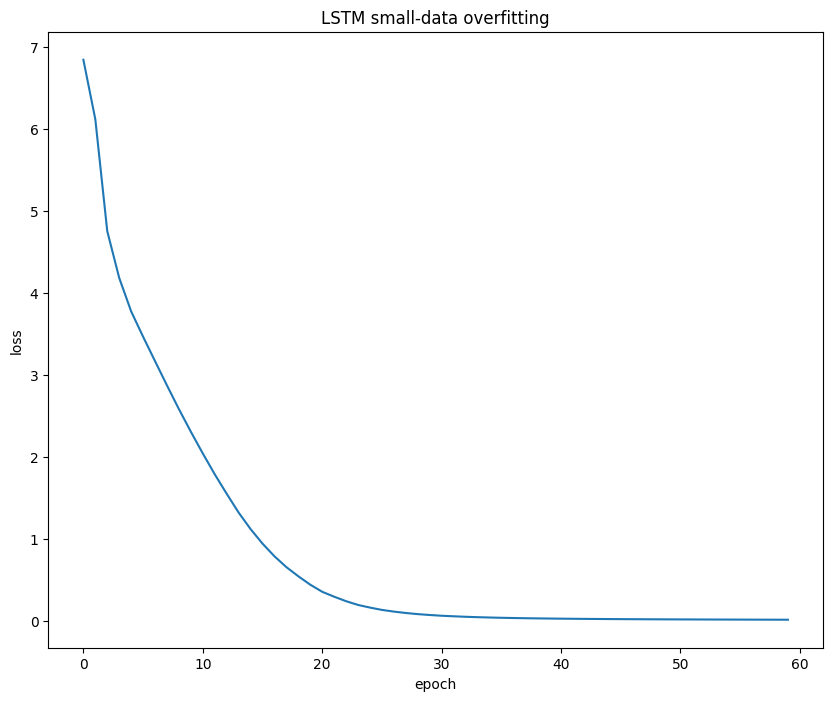

Final LSTM loss: 0.012179611716419458


In [57]:
##############################################################################
# TODO 2.4 (8 points): Choose a configuration that reliably overfits the      #
# 100-example training subset.                                                #
##############################################################################
lstm_wordvec_dim = 128
lstm_hidden_dim = 256
lstm_batch_size = 50
lstm_num_epochs = 60
lstm_learning_rate = 5e-3
##############################################################################
#                         END OF YOUR CODE                                    #
##############################################################################

lstm_loader = DataLoader(small_train, batch_size=lstm_batch_size, shuffle=True)
torch.manual_seed(SEED)
lstm_model = LSTMCaptioner(
    data['word_to_idx'], input_dim=input_dim,
    wordvec_dim=lstm_wordvec_dim, hidden_dim=lstm_hidden_dim,
)
lstm_loss_history = train_captioner(
    lstm_model, lstm_loader, num_epochs=lstm_num_epochs,
    learning_rate=lstm_learning_rate, null_index=null_index, device=device,
)

plt.plot(lstm_loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('LSTM small-data overfitting')
plt.show()
print('Final LSTM loss:', lstm_loss_history[-1])


#### Question 2.5: LSTM Greedy Sampling [code] (4 points)

**Concept Connection**

LSTM decoding follows the same autoregressive process as RNN decoding, but each
step must preserve both the hidden state and the cell state.

**Implementation Guide**

Initialize `h` from the image features and initialize `c` to zeros. Starting
from `<START>`, repeatedly embed the current token, call `self.lstm.cell`, map
the new hidden state to vocabulary logits, take `argmax(dim=1)`, store the
prediction, and feed it into the next step.

| Tensor | Shape |
|---|---|
| current token | `(N,)` |
| hidden and cell states | `(N, H)` each |
| output `captions` | `(N, max_length)` |

**Expected Check:** Sampling runs without gradients and produces an integer
caption tensor for both training and validation features.


GT:   <START> three baseball players on a field being <UNK> by a crowd <END>
Pred: <UNK> a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
Could not download image: HTTP Error 404: Not Found
GT:   <START> giraffes standing in an area of dry grass and small trees <END>
Pred: a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a


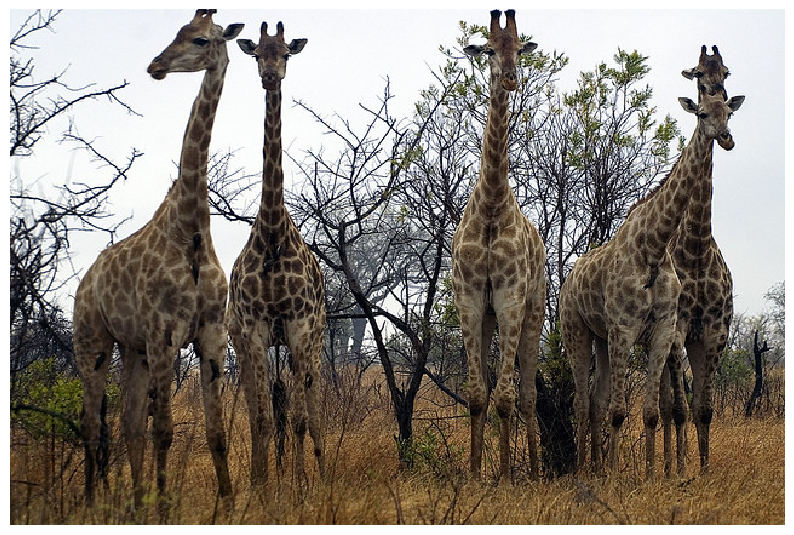

GT:   <START> a group of zebras shown in a outdoor enclosure <END>
Pred: this a a a a a a a a a a a a a a a a a a a a a a a a a a a a a


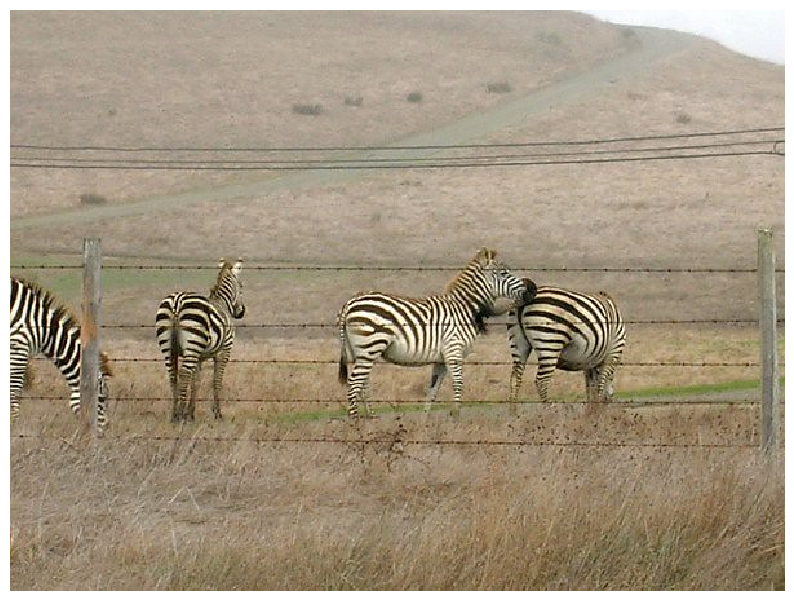

GT:   <START> two transit trains are pulled up at a station with passengers walking <UNK> <END>
Pred: a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a


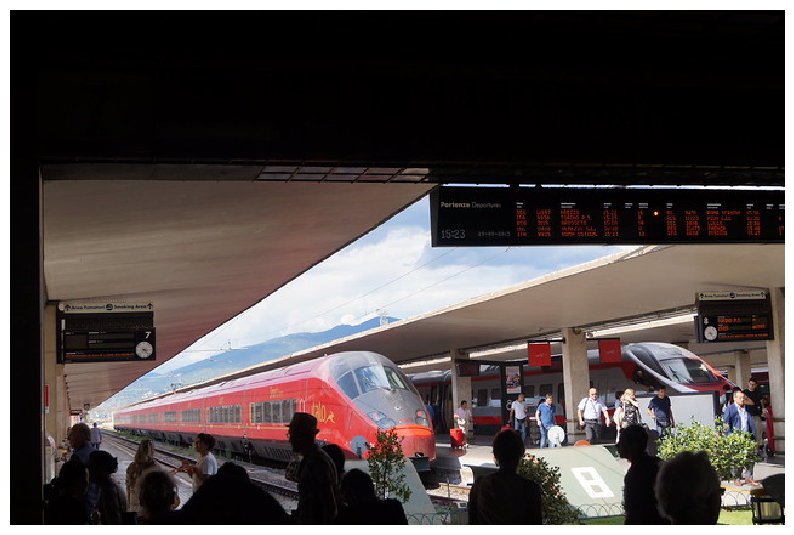

In [58]:
show_samples(lstm_model, data, split='train')
show_samples(lstm_model, data, split='val')


#### Question 2.6: LSTM Gate Activations [written] (4 points)

---

The input, forget, and output gates use sigmoid activations. Why is sigmoid more
appropriate than ReLU for these gates? Discuss the intended interpretation of a
gate and the effect of its output range on the cell state.

$\color{blue}{\textit Your Answer:}$

<!-- ANSWER_START: 2.6 -->

Sigmoid is more appropriate for the input, forget, and output gates because its output is bounded between 0 and 1. This allows each gate to act as a controller for how much information should pass through: a value near 0 blocks the information, while a value near 1 allows most or all of it to pass. In particular, the forget and input gates control how much old information is retained in the cell state and how much new information is added. ReLU is not suitable for this interpretation because its output is unbounded above, so a gate value greater than 1 could amplify the cell state instead of simply controlling information flow, which could make the recurrent state unstable.

<!-- ANSWER_END: 2.6 -->

---


## Submission Checklist

- Fill in the student ID and name.
- Complete every numbered TODO and both written questions.
- Do not use `nn.RNN`, `nn.RNNCell`, `nn.LSTM`, or `nn.LSTMCell` in submitted implementations.
- Confirm that all provided equivalence checks pass.
- Confirm that gradients are present for all model parameters.
- Confirm that the RNN and LSTM small-data losses meet their stated thresholds.
- Restart the runtime and run every cell from top to bottom before submission.
